# Logistic Regression — Attribute Effects via AMEs

This notebook measures the impact of each attribute on the outcome of the incident (`severity`) using **Average Marginal Effects (AMEs)** as the effect metric.

AMEs are computed on the **probability scale**, which ensures that their values are directly interpretable as changes in **P(severity = 1)** associated with each variable. This makes them directly comparable to **SHAP Global E[φ_k]** from tree-based models, as both quantify the average contribution of each feature to the predicted probability.

> **Specificity of logistic regression:** coefficients from logistic regression are naturally estimated in the **log-odds scale**, which are not directly interpretable in terms of probability changes. Therefore, AMEs are obtained by averaging the marginal effects across all observations, translating the model’s nonlinear response into an expected change in probability. For continuous variables, this corresponds to the average partial derivative of the predicted probability with respect to the feature; for binary or categorical variables, it reflects the discrete change in probability when the variable shifts between levels, holding other features constant.


In [ ]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import io

In [5]:
url = "../../database/completo/df_completo_01_uf_br.csv"

# carrega dados
df = pd.read_csv( url, sep=",", encoding="UTF-8")

In [6]:
train_df = df[(df["ano"] >= 2017) & (df["ano"] <= 2024)]
test_df  = df[df["ano"] == 2025]

X_train = train_df.drop(columns=["gravidade", "ano"])
y_train = train_df["gravidade"]

X_test = test_df.drop(columns=["gravidade", "ano"])
y_test = test_df["gravidade"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
# Bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    brier_score_loss,
    precision_recall_curve,
    auc,
    roc_curve,
)

def evaluate_classification(model, X_test, y_test, plot_curves=True):
    """
    Avalia um modelo de classificação binária considerando desbalanceamento de classes.
    Ajusta o threshold para maximizar F1-score da classe minoritária.
    
    Parâmetros:
    - model: modelo treinado com predict_proba
    - X_test: dataframe ou array das features de teste
    - y_test: vetor das labels reais
    - plot_curves: se True, plota ROC e Precision-Recall
    
    Retorna:
    - dicionário com métricas principais
    """
    
    # Predição probabilística
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Ajuste automático do threshold maximizando F1-score
    best_f1 = 0
    best_thresh = 0.5
    thresholds = np.linspace(0.01, 0.99, 99)
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_test, y_pred_t)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    
    # Predição final usando threshold ótimo
    y_pred = (y_prob >= best_thresh).astype(int)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    # Relatório detalhado
    report = classification_report(y_test, y_pred, zero_division=0)
    
    results = {
        "threshold_ótimo": best_thresh,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc_score,
        "brier": brier,
        "confusion_matrix": cm,
        "classification_report": report
    }
    
    # Plots
    if plot_curves:
        # ROC
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
        plt.plot([0,1],[0,1],'--',color='gray')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("Curva ROC")
        plt.legend()
        
        # Precision-Recall
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_vals, precision_vals)
        plt.subplot(1,2,2)
        plt.plot(recall_vals, precision_vals, label=f'PR AUC = {pr_auc:.3f}')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    return results

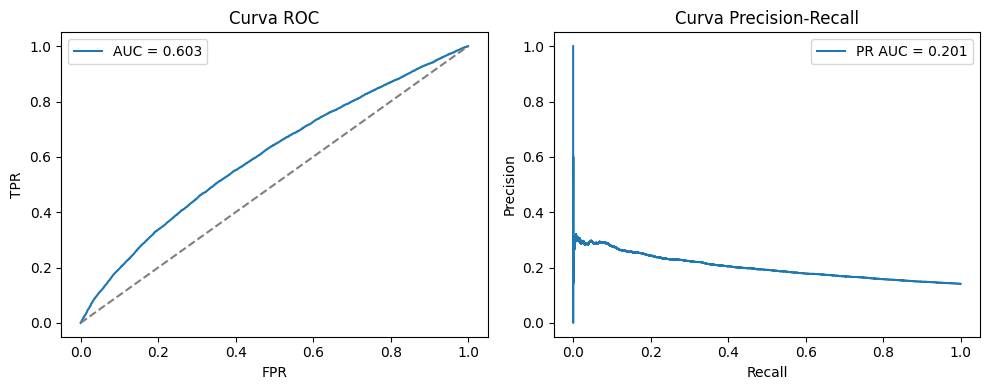

Threshold ótimo: 0.14
Acurácia: 0.6241598672382797
F1-score: 0.27757250325633326
Precision: 0.1904223502808374
Recall: 0.5118125673953534
AUC: 0.6028201731078544
Brier Score: 0.11930987645904421

Matriz de Confusão:
 [[39912 22197]
 [ 4980  5221]]

Relatório completo:
               precision    recall  f1-score   support

           0       0.89      0.64      0.75     62109
           1       0.19      0.51      0.28     10201

    accuracy                           0.62     72310
   macro avg       0.54      0.58      0.51     72310
weighted avg       0.79      0.62      0.68     72310



In [9]:
# model -> modelo treinado (LogisticRegression, RandomForest, etc.)
# X_test, y_test -> dados de teste (ano 2025)

metrics = evaluate_classification(model, X_test, y_test)

# Visualizar principais métricas
print("Threshold ótimo:", metrics["threshold_ótimo"])
print("Acurácia:", metrics["accuracy"])
print("F1-score:", metrics["f1"])
print("Precision:", metrics["precision"])
print("Recall:", metrics["recall"])
print("AUC:", metrics["auc"])
print("Brier Score:", metrics["brier"])
print("\nMatriz de Confusão:\n", metrics["confusion_matrix"])
print("\nRelatório completo:\n", metrics["classification_report"])

In [10]:
# Bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    brier_score_loss,
    precision_recall_curve,
    auc
)
from sklearn.utils import resample

def evaluate_classification_bootstrap(model, X_test, y_test, n_bootstrap=1000, plot_curves=True):
    """
    Avaliação completa de um modelo de classificação binária com:
    - Threshold ótimo (max F1)
    - Métricas por classe
    - Intervalos de confiança via bootstrap
    - Curvas ROC e Precision-Recall
    
    Parâmetros:
    - model: modelo treinado com predict_proba
    - X_test: features de teste
    - y_test: labels reais
    - n_bootstrap: número de reamostragens para IC
    - plot_curves: se True, plota ROC e Precision-Recall
    
    Retorna:
    - dicionário com métricas e IC por bootstrap
    """
    
    # Predição probabilística
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Ajuste automático do threshold maximizando F1-score
    best_f1 = 0
    best_thresh = 0.5
    thresholds = np.linspace(0.01, 0.99, 99)
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_test, y_pred_t)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    
    # Predição final usando threshold ótimo
    y_pred = (y_prob >= best_thresh).astype(int)
    
    # Métricas principais
    metrics = {
        "threshold_ótimo": best_thresh,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_prob),
        "brier": brier_score_loss(y_test, y_prob),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    
    # Bootstrap para IC 95% das métricas
    bootstrap_results = {"accuracy":[], "precision":[], "recall":[], "f1":[]}
    for i in range(n_bootstrap):
        X_resampled, y_resampled = resample(X_test, y_test)
        y_prob_resampled = model.predict_proba(X_resampled)[:,1]
        y_pred_resampled = (y_prob_resampled >= best_thresh).astype(int)
        bootstrap_results["accuracy"].append(accuracy_score(y_resampled, y_pred_resampled))
        bootstrap_results["precision"].append(precision_score(y_resampled, y_pred_resampled, zero_division=0))
        bootstrap_results["recall"].append(recall_score(y_resampled, y_pred_resampled, zero_division=0))
        bootstrap_results["f1"].append(f1_score(y_resampled, y_pred_resampled, zero_division=0))
    
    # Intervalos de confiança 95%
    metrics["CI"] = {}
    for key in bootstrap_results:
        lower = np.percentile(bootstrap_results[key], 2.5)
        upper = np.percentile(bootstrap_results[key], 97.5)
        metrics["CI"][key] = (lower, upper)
    
    # Métricas por classe
    metrics["per_class"] = {
        "precision_0": precision_score(y_test, y_pred, pos_label=0, zero_division=0),
        "recall_0": recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        "f1_0": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    }
    
    # Curvas ROC e Precision-Recall
    if plot_curves:
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_vals, precision_vals)
        
        plt.figure(figsize=(12,5))
        
        plt.subplot(1,2,1)
        plt.plot(fpr, tpr, label=f'AUC = {metrics["auc"]:.3f}')
        plt.plot([0,1],[0,1],'--',color='gray')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("Curva ROC")
        plt.legend()
        
        plt.subplot(1,2,2)
        plt.plot(recall_vals, precision_vals, label=f'PR AUC = {pr_auc:.3f}')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    return metrics

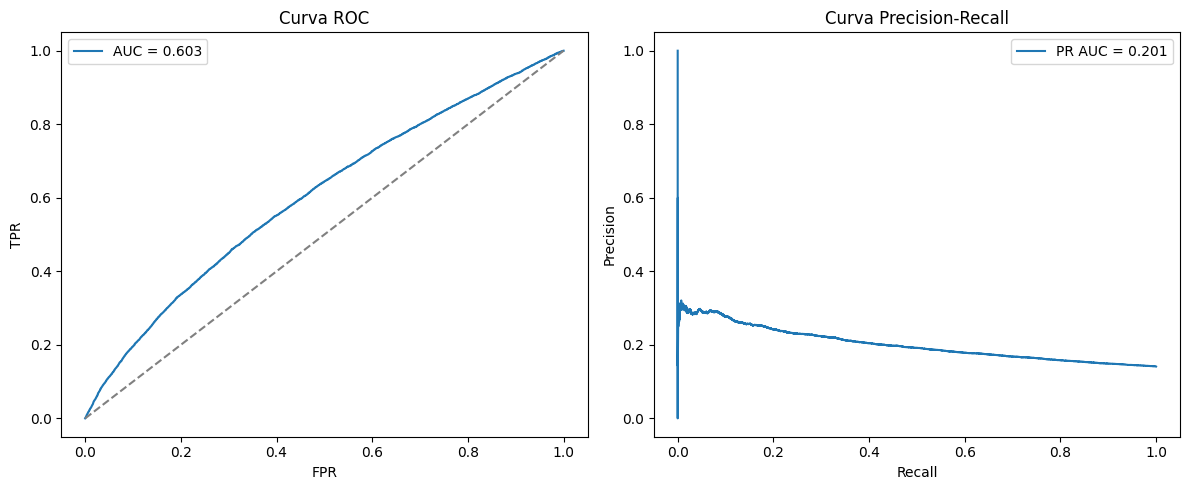

Threshold ótimo: 0.14
Accuracy: 0.6241598672382797 IC 95%: (np.float64(0.6205687318489835), np.float64(0.6276593832111741))
F1-score: 0.27757250325633326 IC 95%: (np.float64(0.27197215750399156), np.float64(0.28335732560416893))
Precision: 0.1904223502808374 IC 95%: (np.float64(0.18583464950591247), np.float64(0.19500712904168388))
Recall: 0.5118125673953534 IC 95%: (np.float64(0.5016201471120115), np.float64(0.5210135613843134))
AUC: 0.6028201731078544
Brier Score: 0.11930987645904421

Matriz de Confusão:
 [[39912 22197]
 [ 4980  5221]]

Métricas por classe:
 {'precision_0': 0.8890670943597968, 'recall_0': 0.6426121818093996, 'f1_0': 0.74601171951664, 'precision_1': 0.1904223502808374, 'recall_1': 0.5118125673953534, 'f1_1': 0.27757250325633326}


In [11]:
# Modelo treinado
# X_test, y_test -> dados de teste (ano 2025)

metrics = evaluate_classification_bootstrap(model, X_test, y_test, n_bootstrap=500)

print("Threshold ótimo:", metrics["threshold_ótimo"])
print("Accuracy:", metrics["accuracy"], "IC 95%:", metrics["CI"]["accuracy"])
print("F1-score:", metrics["f1"], "IC 95%:", metrics["CI"]["f1"])
print("Precision:", metrics["precision"], "IC 95%:", metrics["CI"]["precision"])
print("Recall:", metrics["recall"], "IC 95%:", metrics["CI"]["recall"])
print("AUC:", metrics["auc"])
print("Brier Score:", metrics["brier"])
print("\nMatriz de Confusão:\n", metrics["confusion_matrix"])
print("\nMétricas por classe:\n", metrics["per_class"])

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, brier_score_loss,
    precision_recall_curve, auc
)
from sklearn.utils import resample

def cyclic_amplitude(beta_sin, beta_cos):
    """
    Calcula amplitude cíclica do logit e do efeito marginal.
    """
    amplitude_logit = np.sqrt(beta_sin**2 + beta_cos**2)
    amplitude_ame = amplitude_logit / 4  # aproximação média para logit -> probabilidade
    return {"beta_sin": beta_sin, "beta_cos": beta_cos,
            "amplitude_logit": amplitude_logit, "amplitude_ame": amplitude_ame}

def evaluate_logistic_cyclic(model, X_test, y_test, cyclic_pairs=None,
                             n_bootstrap=500, plot_curves=True):
    """
    Avaliação completa de regressão logística com variáveis cíclicas.
    
    Parâmetros:
    - model: LogisticRegression treinado
    - X_test, y_test: dados de teste
    - cyclic_pairs: lista de tuplas [(sin_name, cos_name, period), ...]
    - n_bootstrap: número de reamostragens para IC
    - plot_curves: se True, plota ROC e PR
    
    Retorna:
    - dicionário com métricas globais, IC bootstrap, e efeito cíclico
    """
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Ajuste de threshold max F1
    best_f1 = 0
    best_thresh = 0.5
    thresholds = np.linspace(0.01, 0.99, 99)
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_test, y_pred_t)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    y_pred = (y_prob >= best_thresh).astype(int)
    
    # Métricas globais
    metrics = {
        "threshold_ótimo": best_thresh,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_prob),
        "brier": brier_score_loss(y_test, y_prob),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    
    # Bootstrap IC 95%
    bootstrap_results = {"accuracy":[],"precision":[],"recall":[],"f1":[]}
    for i in range(n_bootstrap):
        X_res, y_res = resample(X_test, y_test)
        y_prob_res = model.predict_proba(X_res)[:,1]
        y_pred_res = (y_prob_res >= best_thresh).astype(int)
        bootstrap_results["accuracy"].append(accuracy_score(y_res, y_pred_res))
        bootstrap_results["precision"].append(precision_score(y_res, y_pred_res, zero_division=0))
        bootstrap_results["recall"].append(recall_score(y_res, y_pred_res, zero_division=0))
        bootstrap_results["f1"].append(f1_score(y_res, y_pred_res, zero_division=0))
    
    metrics["CI"] = {k:(np.percentile(v,2.5), np.percentile(v,97.5)) for k,v in bootstrap_results.items()}
    
    # Avaliação de variáveis cíclicas
    cyclic_effects = {}
    if cyclic_pairs:
        for sin_name, cos_name, period in cyclic_pairs:
            idx_sin = list(X_test.columns).index(sin_name)
            idx_cos = list(X_test.columns).index(cos_name)
            beta_sin = model.coef_[0][idx_sin]
            beta_cos = model.coef_[0][idx_cos]
            cyclic_effects[f"{sin_name}_{cos_name}"] = cyclic_amplitude(beta_sin, beta_cos)
    
    metrics["cyclic_effects"] = cyclic_effects
    
    # Plots ROC e Precision-Recall
    if plot_curves:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_vals, precision_vals)
        
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(fpr, tpr, label=f'AUC = {metrics["auc"]:.3f}')
        plt.plot([0,1],[0,1],'--',color='gray')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("Curva ROC")
        plt.legend()
        
        plt.subplot(1,2,2)
        plt.plot(recall_vals, precision_vals, label=f'PR AUC = {pr_auc:.3f}')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    return metrics

In [ ]:
# Probabilidades no conjunto de treino
p_train = model.predict_proba(X_train)[:, 1]

# Derivada logística média
mean_derivative = np.mean(p_train * (1 - p_train))

# Coeficientes
betas = model.coef_[0]

# AME
ame = betas * mean_derivative

ame_df = pd.DataFrame({
    "variavel": X_train.columns,
    "coeficiente_logit": betas,
    "AME": ame
}).sort_values("AME", key=np.abs, ascending=False)

print(ame_df)

                  variavel  coeficiente_logit       AME
5               tipo_pista          -0.199743 -0.022118
17                 declive           0.157100  0.017396
10        total_ocorrencia          -0.152582 -0.016896
19      intersecao_de_vias          -0.146470 -0.016219
8                  vel_max           0.126518  0.014010
9        distancia_radar_m           0.118738  0.013148
4   condicao_metereologica          -0.106258 -0.011766
15               turno_sin          -0.102607 -0.011362
16               turno_cos           0.097712  0.010820
0                       uf          -0.088061 -0.009751
12          dia_semana_cos           0.060390  0.006687
6                 uso_solo          -0.056962 -0.006308
18                    reta          -0.054028 -0.005983
1                       br           0.028925  0.003203
11          dia_semana_sin          -0.027064 -0.002997
13                 mes_sin          -0.024480 -0.002711
3              sentido_via           0.016470  0

In [ ]:
def cyclic_amplitude(model, sin_name, cos_name, feature_names):
    
    idx_sin = list(feature_names).index(sin_name)
    idx_cos = list(feature_names).index(cos_name)
    
    beta_sin = model.coef_[0][idx_sin]
    beta_cos = model.coef_[0][idx_cos]
    
    amplitude = np.sqrt(beta_sin**2 + beta_cos**2)
    
    return {
        "beta_sin": beta_sin,
        "beta_cos": beta_cos,
        "amplitude_logit": amplitude
    }

print(cyclic_amplitude(model, "turno_sin", "turno_cos", X_train.columns))
print(cyclic_amplitude(model, "mes_sin", "mes_cos", X_train.columns))
print(cyclic_amplitude(model, "dia_semana_sin", "dia_semana_cos", X_train.columns))

{'beta_sin': np.float64(-0.10260744525216162), 'beta_cos': np.float64(0.09771222719952714), 'amplitude_logit': np.float64(0.14168968616475708)}
{'beta_sin': np.float64(-0.024479753117554043), 'beta_cos': np.float64(-0.0031504080086915856), 'amplitude_logit': np.float64(0.02468164061235851)}
{'beta_sin': np.float64(-0.027064042646095028), 'beta_cos': np.float64(0.0603903451096781), 'amplitude_logit': np.float64(0.06617745980933139)}


In [ ]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_sm).fit()

# Índices das variáveis
idx_sin = list(X_sm.columns).index("turno_sin")
idx_cos = list(X_sm.columns).index("turno_cos")

R = np.zeros((2, len(logit_model.params)))
R[0, idx_sin] = 1
R[1, idx_cos] = 1

wald_test = logit_model.wald_test(R)
print(wald_test)

Optimization terminated successfully.
         Current function value: 0.376329
         Iterations 7
<Wald test (chi2): statistic=[[1255.93772626]], p-value=1.890548989334313e-273, df_denom=2>


c:\Users\Diego\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [ ]:
def cyclic_ame(model, X, sin_name, cos_name):
    
    p = model.predict_proba(X)[:, 1]
    mean_derivative = np.mean(p * (1 - p))
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    beta_sin = model.coef_[0][idx_sin]
    beta_cos = model.coef_[0][idx_cos]
    
    amplitude = np.sqrt(beta_sin**2 + beta_cos**2)
    
    ame_cyclic = amplitude * mean_derivative
    
    return ame_cyclic

print(cyclic_ame(model, X_train, "dia_semana_sin", "dia_semana_cos"))
print(cyclic_ame(model, X_train, "turno_sin", "turno_cos"))
print(cyclic_ame(model, X_train, "mes_sin", "mes_cos"))

0.007327953506730642
0.01568956311696011
0.0027330440817508513


In [ ]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_sm).fit()

# Índices das variáveis
idx_sin = list(X_sm.columns).index("turno_sin")
idx_cos = list(X_sm.columns).index("turno_cos")

R = np.zeros((2, len(logit_model.params)))
R[0, idx_sin] = 1
R[1, idx_cos] = 1

wald_test = logit_model.wald_test(R)
print(wald_test)

Optimization terminated successfully.
         Current function value: 0.376329
         Iterations 7
<Wald test (chi2): statistic=[[1255.93772626]], p-value=1.890548989334313e-273, df_denom=2>


c:\Users\Diego\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cyclic_effect(model, sin_name, cos_name, period=12):
    
    idx_sin = list(X_train.columns).index(sin_name)
    idx_cos = list(X_train.columns).index(cos_name)
    
    beta_sin = model.coef_[0][idx_sin]
    beta_cos = model.coef_[0][idx_cos]
    
    angles = np.linspace(0, period-1, period)
    
    logit_effect = (
        beta_sin * np.sin(2*np.pi*angles/period) +
        beta_cos * np.cos(2*np.pi*angles/period)
    )
    
    prob_effect = 1 / (1 + np.exp(-logit_effect))
    
    plt.plot(angles, prob_effect)
    plt.xlabel("Período")
    plt.ylabel("Probabilidade relativa")
    plt.title("Efeito Cíclico")
    plt.show()

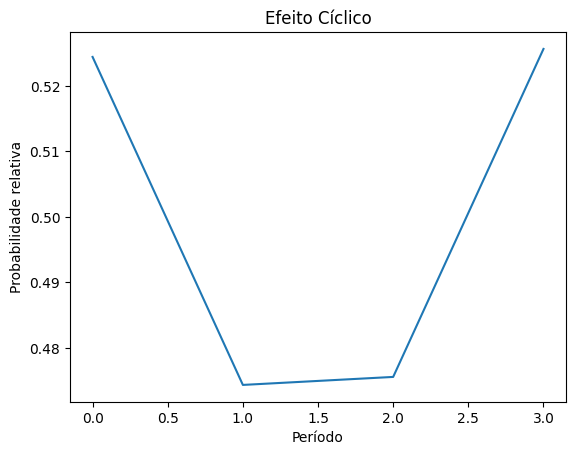

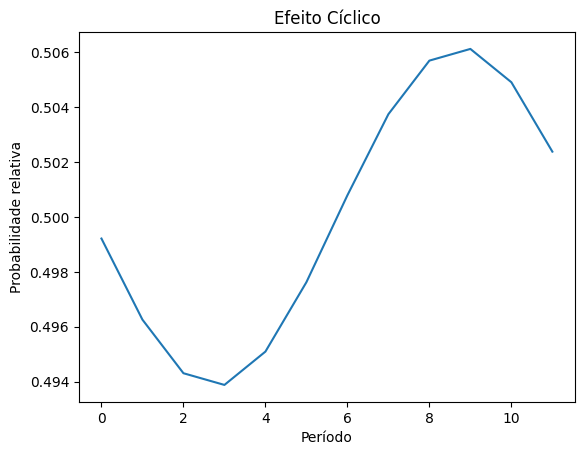

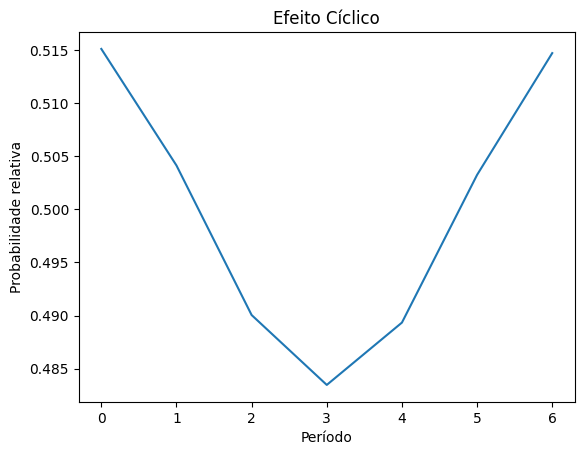

In [ ]:
plot_cyclic_effect(model, "turno_sin", "turno_cos", 4)
plot_cyclic_effect(model, "mes_sin", "mes_cos", 12)
plot_cyclic_effect(model, "dia_semana_sin", "dia_semana_cos", 7)